# Load Scale Recalibration, Proof of Concept

Derives `load_options.scale` (see `scripts/build_demand_profiles.py`, where it's applied as `el_load["Electricity demand"] *= scale`) from Ember reference demand, instead of hand tuning it as has been done so far (`config.zm.valid_2023.yaml` currently has `scale: 1.25`, derived informally and undocumented).

If the approach holds up, the logic here is the candidate to promote into a proper rule (mirroring the existing `build_reference_generation` rule in `rules/postprocessing.smk`) later.

**Data source**: `data/validation/ember_yearly_electricity_data.csv`, Ember's "Yearly Electricity Data" (generation-oriented) release. For a given country/year, the demand figure is the row where `Electricity source == "Demand"`; its value is stored under the `Generation (TWh)` column, which Ember reuses across every `Electricity source` row (generation, net imports, demand, ...).

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd

## Parameters

Edit these to calibrate a different year / resolution / scenario. All `dispatch_validation` scenarios (2020–2024) can reuse this notebook by changing `YEAR` and `RUN_NAME`.

In [2]:
YEAR = 2023
COUNTRY_ISO3 = "ZMB"

RUN_NAME = "validation_dispatch_zambia_2023"
DEMAND_PROFILES_PATH = f"../resources/{RUN_NAME}/demand_profiles.csv"

# Scale the demand_profiles.csv above was actually built with — check
# logs/<run_name>/build_demand_profiles.log for "Load data scaled with scaling
# factor X.". Set to 1.0 once you rebuild the profile cleanly with
# load_options.scale: 1.0, which is the recommended way to get a final number.
CURRENT_SCALE = 0.9

EMBER_RAW_PATH = "../data/validation/ember_yearly_electricity_data.csv"

## 1. Reference demand (Ember)

Parsed directly from the raw release: filter to the country, then to the `"Demand"` pseudo-source row per year.

In [3]:
ember_raw = pd.read_csv(EMBER_RAW_PATH)

reference_table = (
    ember_raw[
        (ember_raw["ISO 3 code"] == COUNTRY_ISO3)
        & (ember_raw["Electricity source"] == "Demand")
    ][["Year", "Generation (TWh)"]]
    .rename(columns={"Year": "year", "Generation (TWh)": "demand_twh"})
    .sort_values("year")
    .reset_index(drop=True)
)

assert not reference_table.empty, f"No Ember demand rows found for {COUNTRY_ISO3}"

reference_demand_twh = float(
    reference_table.loc[reference_table["year"] == YEAR, "demand_twh"].iloc[0]
)
print(f"Ember reference demand, {COUNTRY_ISO3} {YEAR}: {reference_demand_twh:.3f} TWh")
reference_table.tail()

Ember reference demand, ZMB 2023: 16.090 TWh


,year,demand_twh
20,2020,14.02
21,2021,15.59
22,2022,16.43
23,2023,16.09
24,2024,16.60


## 2. Modelled demand at scale=1.0

`demand_profiles.csv` is hourly MW per bus, so summing it and dividing by 1e6 gives annual TWh. It's then un-scaled back to what `scale=1.0` would have produced.

In [4]:
demand_profiles = pd.read_csv(DEMAND_PROFILES_PATH, index_col=0)

total_demand_twh = demand_profiles.sum().sum() / 1e6  # hourly resolution: MW * 1h = MWh
baseline_demand_twh = total_demand_twh / CURRENT_SCALE

print(f"Model demand as built (scale={CURRENT_SCALE}): {total_demand_twh:.3f} TWh")
print(
    f"Model demand backed out to scale=1.0: {baseline_demand_twh:.3f} TWh"
)

Model demand as built (scale=0.9): 14.318 TWh
Model demand backed out to scale=1.0: 15.909 TWh


## 3. Recommended scale

In [5]:
recommended_scale = reference_demand_twh / baseline_demand_twh
print(f"Recommended load_options.scale for {YEAR}: {recommended_scale:.4f}")

Recommended load_options.scale for 2023: 1.0114


## 4. Sanity check plot

Ember's demand trend over time, with the model's current (uncalibrated) and recalibrated points for `YEAR` overlaid.

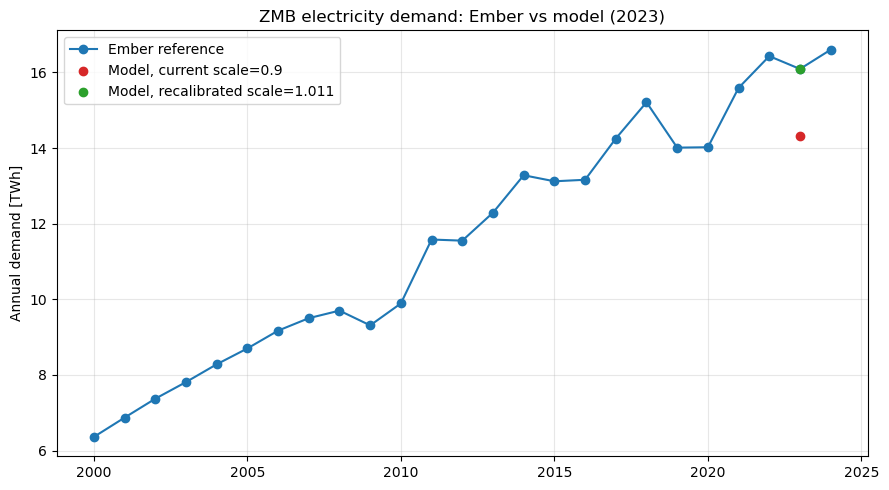

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    reference_table["year"],
    reference_table["demand_twh"],
    marker="o",
    label="Ember reference",
    color="#1f77b4",
)
ax.scatter(
    [YEAR],
    [baseline_demand_twh * CURRENT_SCALE],
    color="#d62728",
    zorder=5,
    label=f"Model, current scale={CURRENT_SCALE}",
)
ax.scatter(
    [YEAR],
    [baseline_demand_twh * recommended_scale],
    color="#2ca02c",
    zorder=5,
    label=f"Model, recalibrated scale={recommended_scale:.3f}",
)
ax.set_ylabel("Annual demand [TWh]")
ax.set_title(f"{COUNTRY_ISO3} electricity demand: Ember vs model ({YEAR})")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()